# Notebook for the 1000 Runs Ensemble

In [325]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3
import numpy as np
import matplotlib.pyplot as plt

In [326]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [327]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "config")

In [328]:
os.makedirs(SSP_DIR_PATH, exist_ok=True)

In [329]:
edau = EDAUtils()

## 1) Pull data from AWS S3


In [330]:
aws_config = edau.read_yaml(os.path.join(CONFIG_DIR_PATH, "aws_credentials_config.yaml"))
profile_name = aws_config["profile_name"]
bucket_name = aws_config["bucket_name"]
# Set your profile
session = boto3.Session(profile_name=profile_name)

# Create an S3 client or resource
s3 = session.resource('s3')

run_id = "sisepuede_run_2025-11-12t22;19;28.194097" #NOTE: Update this for each run

# Define folder prefix
prefix = f'transfers/{run_id}/'  # this is like the "folder" in S3

In [331]:
# Local destination
destination = os.path.join(SSP_DIR_PATH, run_id)
if os.path.exists(destination) and os.listdir(destination):
    print(f"Destination '{destination}' already exists and is not empty. Skipping download.")
else:
    os.makedirs(destination, exist_ok=True)
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=prefix):
        if obj.key.endswith('/') or "transformations" in obj.key:  # skip directories and transformations
            continue
        target_path = os.path.join(destination, os.path.basename(obj.key))
        print(f"Downloading {obj.key} to {target_path}")
        bucket.download_file(obj.key, target_path)

Destination '/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/data/ssp/sisepuede_run_2025-11-12t22;19;28.194097' already exists and is not empty. Skipping download.


In [332]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)
print(SIMULATION_DIR_PATH)

/Users/tony/Documents/sisepuede_modeling/ssp_uganda_data/metamodel/data/ssp/sisepuede_run_2025-11-12t22;19;28.194097


## 2) Load and Process LHC Samples Dataframes (Our Predictors)

In [333]:
# Load lhc samples dfs
lhs_exogenous_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES.csv"))
lhs_levers_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_LEVER_EFFECTS.csv"))

In [334]:
lhs_exogenous_df.head()

,region,design_id,future_id,60,61,62,63,64,65,66,67,68
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [335]:
lhs_levers_df.head()

,region,design_id,future_id,1,2,3,4,5,6,7,...,1711,1712,1714,1726,1727,1730,1731,1733,1735,1736
0,uganda,-1,1,0.101339,0.473404,0.160028,0.138651,0.884491,0.060244,0.020961,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.464099,0.820027,0.047124,0.035410,0.611181,0.211565,0.518128,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.659192,0.680496,0.143914,0.291818,0.981122,0.678408,0.612630,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.398393,0.357480,0.884181,0.014265,0.222220,0.279840,0.861182,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.460167,0.770275,0.959465,0.119969,0.735865,0.586344,0.698312,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [336]:
# Add suffix to lever columns to distinguish them later
lhs_levers_df = lhs_levers_df.add_suffix('_L')
lhs_levers_df = lhs_levers_df.rename(columns={"region_L": "region", "design_id_L": "design_id", "future_id_L": "future_id"})
lhs_levers_df.head()

,region,design_id,future_id,1_L,2_L,3_L,4_L,5_L,6_L,7_L,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,uganda,-1,1,0.101339,0.473404,0.160028,0.138651,0.884491,0.060244,0.020961,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.464099,0.820027,0.047124,0.035410,0.611181,0.211565,0.518128,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.659192,0.680496,0.143914,0.291818,0.981122,0.678408,0.612630,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.398393,0.357480,0.884181,0.014265,0.222220,0.279840,0.861182,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.460167,0.770275,0.959465,0.119969,0.735865,0.586344,0.698312,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [337]:
# Add suffix to uncertainties columns to distinguish them later
lhs_exogenous_df = lhs_exogenous_df.add_suffix('_X')
lhs_exogenous_df = lhs_exogenous_df.rename(columns={"region_X": "region", "design_id_X": "design_id", "future_id_X": "future_id"})
lhs_exogenous_df.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,68_X
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [338]:
# check unique design ids to ensure they match
print(lhs_exogenous_df.design_id.unique())
print(lhs_levers_df.design_id.unique())

[-1  0  3  4]
[-1  0  3  4]


In [339]:
# print shapes
print(lhs_exogenous_df.shape)
print(lhs_levers_df.shape)

(4000, 12)
(4000, 86)


In [340]:
lhs_df_merged = pd.merge(lhs_exogenous_df, lhs_levers_df, on=["region", "design_id", "future_id"], how="inner")
lhs_df_merged.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [341]:
lhs_df_merged = lhs_df_merged.drop(columns=["region"])
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [342]:
# Check shape
print(lhs_df_merged.shape)

(4000, 94)


In [343]:
# NOTE: check col names, there should be no duplicates
cols = lhs_df_merged.columns
duplicates = cols[cols.duplicated()]
print("Duplicate columns:", list(duplicates))

Duplicate columns: []


In [344]:
lhs_df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 94 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   design_id  4000 non-null   int64  
 1   future_id  4000 non-null   int64  
 2   60_X       4000 non-null   float64
 3   61_X       4000 non-null   float64
 4   62_X       4000 non-null   float64
 5   63_X       4000 non-null   float64
 6   64_X       4000 non-null   float64
 7   65_X       4000 non-null   float64
 8   66_X       4000 non-null   float64
 9   67_X       4000 non-null   float64
 10  68_X       4000 non-null   float64
 11  1_L        4000 non-null   float64
 12  2_L        4000 non-null   float64
 13  3_L        4000 non-null   float64
 14  4_L        4000 non-null   float64
 15  5_L        4000 non-null   float64
 16  6_L        4000 non-null   float64
 17  7_L        4000 non-null   float64
 18  8_L        4000 non-null   float64
 19  9_L        4000 non-null   float64
 20  10_L    

## 3) Load DFs for Target Variable Creation

### Load SISEPUEDE WIDE_INPUTS_OUTPUTS

In [345]:
wide_inputs_outputs_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "sisepuede_results_IDE_2025-11-12t22;19;28.194097.csv"))
wide_inputs_outputs_df

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
0,0,uganda,4,634960.593061,2.025945e+06,156073.139455,1.131815e+06,505.429083,5.138329e+05,2.915383e+06,...,4.042769,0.369457,12.786390,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200
1,0,uganda,5,640126.452982,2.042427e+06,157342.906406,1.141024e+06,509.541112,5.180133e+05,2.939102e+06,...,4.144474,0.431364,14.592304,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287
2,0,uganda,6,642767.262368,2.050853e+06,157992.016628,1.145731e+06,511.643198,5.201503e+05,2.951227e+06,...,3.876473,0.487391,14.491826,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363
3,0,uganda,7,645322.479649,2.059006e+06,158620.088334,1.150285e+06,513.677153,5.222181e+05,2.962959e+06,...,3.796968,0.497802,14.390979,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672
4,0,uganda,8,647798.760608,2.066907e+06,159228.757514,1.154699e+06,515.648274,5.242220e+05,2.974329e+06,...,3.683509,0.505170,14.286685,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103891,375374,uganda,51,780216.190070,2.211158e+06,128906.203719,1.498286e+06,814.896050,1.255106e+06,1.314838e+06,...,6.414576,0.383571,10.755071,3.430064,41.285578,23.598980,4.507728,7.156791,24.652466,6.340611
103892,375374,uganda,52,788495.101017,2.233603e+06,130124.813888,1.514142e+06,823.604751,1.269260e+06,1.324660e+06,...,6.429844,0.376376,11.075056,3.369158,41.261605,23.891082,4.624753,7.045961,25.081728,6.143483
103893,375374,uganda,53,796799.449638,2.256356e+06,131362.610944,1.529967e+06,832.212225,1.283210e+06,1.335208e+06,...,6.446790,0.369181,11.366478,3.306374,41.234818,24.188186,4.709914,6.941360,25.517470,5.941191
103894,375374,uganda,54,805118.957301,2.279368e+06,132613.252754,1.545746e+06,840.714329,1.296978e+06,1.346316e+06,...,6.465401,0.361973,11.632178,3.241627,41.204897,24.490275,4.763500,6.843516,25.959593,5.734102


In [346]:
wide_inputs_outputs_df.primary_id.nunique()

1998

### Load CB Wide File

In [347]:
cb_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "wide_cb_data_lhc_sisepuede_run_2025-11-12t22;19;28.194097.csv"))
cb_df.head()

,primary_id,future_id,strategy_code,Year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,...,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,0,AGRC:DEC_CH4_RICE,2019,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,1001,0,AGRC:DEC_CH4_RICE,2020,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2,1001,0,AGRC:DEC_CH4_RICE,2021,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
3,1001,0,AGRC:DEC_CH4_RICE,2022,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,1001,0,AGRC:DEC_CH4_RICE,2023,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [348]:
print("cb_df shape:", cb_df.shape)
print("cb_unique primary_id count:", cb_df.primary_id.nunique())

cb_df shape: (103844, 21)
cb_unique primary_id count: 1997


## 4) Data Prep

### SISEPUEDE Emission data

We want to get the subsector totals to then sum them up and compute the economy-wide emissions total

In [349]:
# Get the subsector total variables
subsector_total_vars = [c for c in wide_inputs_outputs_df.columns if "emission_co2e_subsector_total" in c]

In [350]:
# Filter to only subsector total columns and primary_id, time_period
la_emissions_df = wide_inputs_outputs_df[["primary_id", "time_period"] + subsector_total_vars]
la_emissions_df.head()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
0,0,4,2.149236,0.0,50.251724,0.000000e+00,-10.894251,4.042769,0.369457,12.786390,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200
1,0,5,2.231574,0.0,50.438607,0.000000e+00,-10.930650,4.144474,0.431364,14.592304,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287
2,0,6,2.361532,0.0,49.334470,0.000000e+00,-10.864787,3.876473,0.487391,14.491826,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363
3,0,7,2.366993,0.0,50.653396,0.000000e+00,-10.798336,3.796968,0.497802,14.390979,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672
4,0,8,2.397417,0.0,52.081951,4.313241e-20,-10.731444,3.683509,0.505170,14.286685,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560


In [351]:
la_emissions_df.tail()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
103891,375374,51,5.658820,-0.257085,4.186917,0.000113,-12.050530,6.414576,0.383571,10.755071,3.430064,41.285578,23.598980,4.507728,7.156791,24.652466,6.340611
103892,375374,52,5.767302,-0.263677,4.241932,0.000113,-11.811217,6.429844,0.376376,11.075056,3.369158,41.261605,23.891082,4.624753,7.045961,25.081728,6.143483
103893,375374,53,5.875665,-0.270269,4.296581,0.000113,-11.569031,6.446790,0.369181,11.366478,3.306374,41.234818,24.188186,4.709914,6.941360,25.517470,5.941191
103894,375374,54,5.983862,-0.276860,4.350721,0.000113,-11.324813,6.465401,0.361973,11.632178,3.241627,41.204897,24.490275,4.763500,6.843516,25.959593,5.734102
103895,375374,55,6.091366,-0.283452,4.404336,0.000113,-11.079211,6.485681,0.354738,11.401411,3.174863,41.171908,24.797897,4.775873,6.752535,26.409307,5.522618


In [352]:
# Sum all the subsector emission columns across axis=1
la_emission_total_df = la_emissions_df.copy()
la_emission_total_df["emission_total"] = la_emission_total_df[subsector_total_vars].sum(axis=1)
la_emission_total_df.head()

,primary_id,time_period,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso,emission_total
0,0,4,2.149236,0.0,50.251724,0.000000e+00,-10.894251,4.042769,0.369457,12.786390,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200,113.224620
1,0,5,2.231574,0.0,50.438607,0.000000e+00,-10.930650,4.144474,0.431364,14.592304,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287,116.233315
2,0,6,2.361532,0.0,49.334470,0.000000e+00,-10.864787,3.876473,0.487391,14.491826,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363,115.725414
3,0,7,2.366993,0.0,50.653396,0.000000e+00,-10.798336,3.796968,0.497802,14.390979,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672,117.989134
4,0,8,2.397417,0.0,52.081951,4.313241e-20,-10.731444,3.683509,0.505170,14.286685,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560,120.416309


In [353]:
# Keep only the primary_id, time_period, and emission_total columns
la_emission_total_df = la_emission_total_df[["primary_id", "time_period", "emission_total"]]
la_emission_total_df.head()

,primary_id,time_period,emission_total
0,0,4,113.224620
1,0,5,116.233315
2,0,6,115.725414
3,0,7,117.989134
4,0,8,120.416309


In [354]:
la_emission_total_df.tail()

,primary_id,time_period,emission_total
103891,375374,51,126.063671
103892,375374,52,127.233500
103893,375374,53,128.354821
103894,375374,54,129.430084
103895,375374,55,129.979982


In [355]:
# aggregate data by primary_id summing the emissions
la_emission_df_sum_agg = la_emission_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_emission_df_sum_agg = la_emission_df_sum_agg.drop(columns=["time_period"])
la_emission_df_sum_agg.head()

,primary_id,emission_total
0,0,10256.854756
1,1001,10256.854756
2,2002,10256.854756
3,3003,10256.854756
4,4004,10256.854756


<Axes: title={'center': 'Distribution of Total Emissions'}, ylabel='Frequency'>

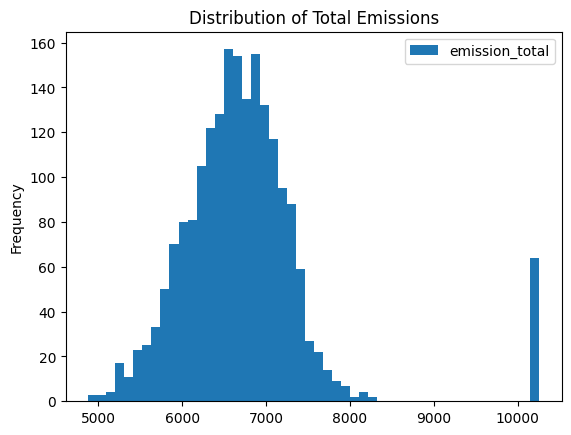

In [356]:
# Check distribution of emission_total
la_emission_df_sum_agg.plot(kind='hist', y='emission_total', bins=50, title='Distribution of Total Emissions')

In [357]:
# Print shape
print(la_emission_df_sum_agg.shape)
print(la_emission_df_sum_agg.primary_id.nunique())

(1998, 2)
1998


### CB data

We want to fill nulls with zeros and aggregate the cost fields to have single records per primary id

In [358]:
cb_df.head()

,primary_id,future_id,strategy_code,Year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,...,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,0,AGRC:DEC_CH4_RICE,2019,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,1001,0,AGRC:DEC_CH4_RICE,2020,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2,1001,0,AGRC:DEC_CH4_RICE,2021,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
3,1001,0,AGRC:DEC_CH4_RICE,2022,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,1001,0,AGRC:DEC_CH4_RICE,2023,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [359]:
cb_df.isnull().sum()

primary_id                 0
future_id                  0
strategy_code              0
Year                       0
air_pollution         100516
congestion            100516
consumer_savings        3120
crop_value            100516
ecosystem_services    100516
env_pollution         100516
fuel_cost             100516
human_health               0
ippu_value            100516
land_pollution        100516
lvst_value            100516
road_safety           100516
sector_specific       100516
system_cost           100516
technical_cost             0
technical_savings     103376
water_pollution       100516
dtype: int64

In [360]:
cb_df = cb_df.fillna(0)
cb_df.isnull().sum()

primary_id            0
future_id             0
strategy_code         0
Year                  0
air_pollution         0
congestion            0
consumer_savings      0
crop_value            0
ecosystem_services    0
env_pollution         0
fuel_cost             0
human_health          0
ippu_value            0
land_pollution        0
lvst_value            0
road_safety           0
sector_specific       0
system_cost           0
technical_cost        0
technical_savings     0
water_pollution       0
dtype: int64

In [361]:
cb_df.columns

Index(['primary_id', 'future_id', 'strategy_code', 'Year', 'air_pollution',
       'congestion', 'consumer_savings', 'crop_value', 'ecosystem_services',
       'env_pollution', 'fuel_cost', 'human_health', 'ippu_value',
       'land_pollution', 'lvst_value', 'road_safety', 'sector_specific',
       'system_cost', 'technical_cost', 'technical_savings',
       'water_pollution'],
      dtype='object')

In [362]:
cb_df = cb_df.drop(columns=["strategy_code", "future_id"])

In [363]:
cb_df

,primary_id,Year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,fuel_cost,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,2019,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,1001,2020,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,1001,2021,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,1001,2022,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1001,2023,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103839,375374,2066,0.0,0.0,29.128911,0.0,0.0,0.0,0.0,17.906486,0.0,0.0,0.0,0.0,0.0,0.0,-1.756948,0.0,0.0
103840,375374,2067,0.0,0.0,30.275406,0.0,0.0,0.0,0.0,18.583429,0.0,0.0,0.0,0.0,0.0,0.0,-1.828242,0.0,0.0
103841,375374,2068,0.0,0.0,31.443209,0.0,0.0,0.0,0.0,19.270369,0.0,0.0,0.0,0.0,0.0,0.0,-1.901486,0.0,0.0
103842,375374,2069,0.0,0.0,32.632247,0.0,0.0,0.0,0.0,19.966958,0.0,0.0,0.0,0.0,0.0,0.0,-1.976759,0.0,0.0


In [364]:
# --- Define periods ---
periods = {
    "y1": (2026, 2040),
    "y2": (2041, 2055),
    "y3": (2056, 2070)
}

# --- Select all cost/benefit columns automatically (exclude ID and Year) ---
value_cols = [c for c in cb_df.columns if c not in ["primary_id", "Year"]]

# --- Function to tag periods ---
def assign_period(year):
    for name, (start, end) in periods.items():
        if start <= year <= end:
            return name
    return None  # years outside defined windows

cb_df["period"] = cb_df["Year"].apply(assign_period)

# --- Filter only period years ---
df_period = cb_df.dropna(subset=["period"])

# --- Mean & max per period ---
period_stats = (
    df_period
    .groupby(["primary_id", "period"])[value_cols]
    .agg(["mean", "max"])
)

# Move 'period' from index to columns -> (col, stat, period)
df_out = period_stats.unstack("period")

# Flatten MultiIndex columns: (col, stat, period) -> "col_stat_period"
df_out.columns = [
    f"{col}_{stat}_{period}"
    for col, stat, period in df_out.columns
]

df_out = df_out.reset_index()

# --- Overall mean across all years ---
overall_mean = (
    cb_df.groupby("primary_id")[value_cols]
    .mean()
    .add_suffix("_overall_mean")
    .reset_index()
)

# --- Merge results ---
cb_df_agg = df_out.merge(overall_mean, on="primary_id", how="left")

cb_df_agg.head()


,primary_id,air_pollution_mean_y1,air_pollution_mean_y2,air_pollution_mean_y3,air_pollution_max_y1,air_pollution_max_y2,air_pollution_max_y3,congestion_mean_y1,congestion_mean_y2,congestion_mean_y3,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.003193,0.0,0.0
1,2002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,3003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,4004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,5005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


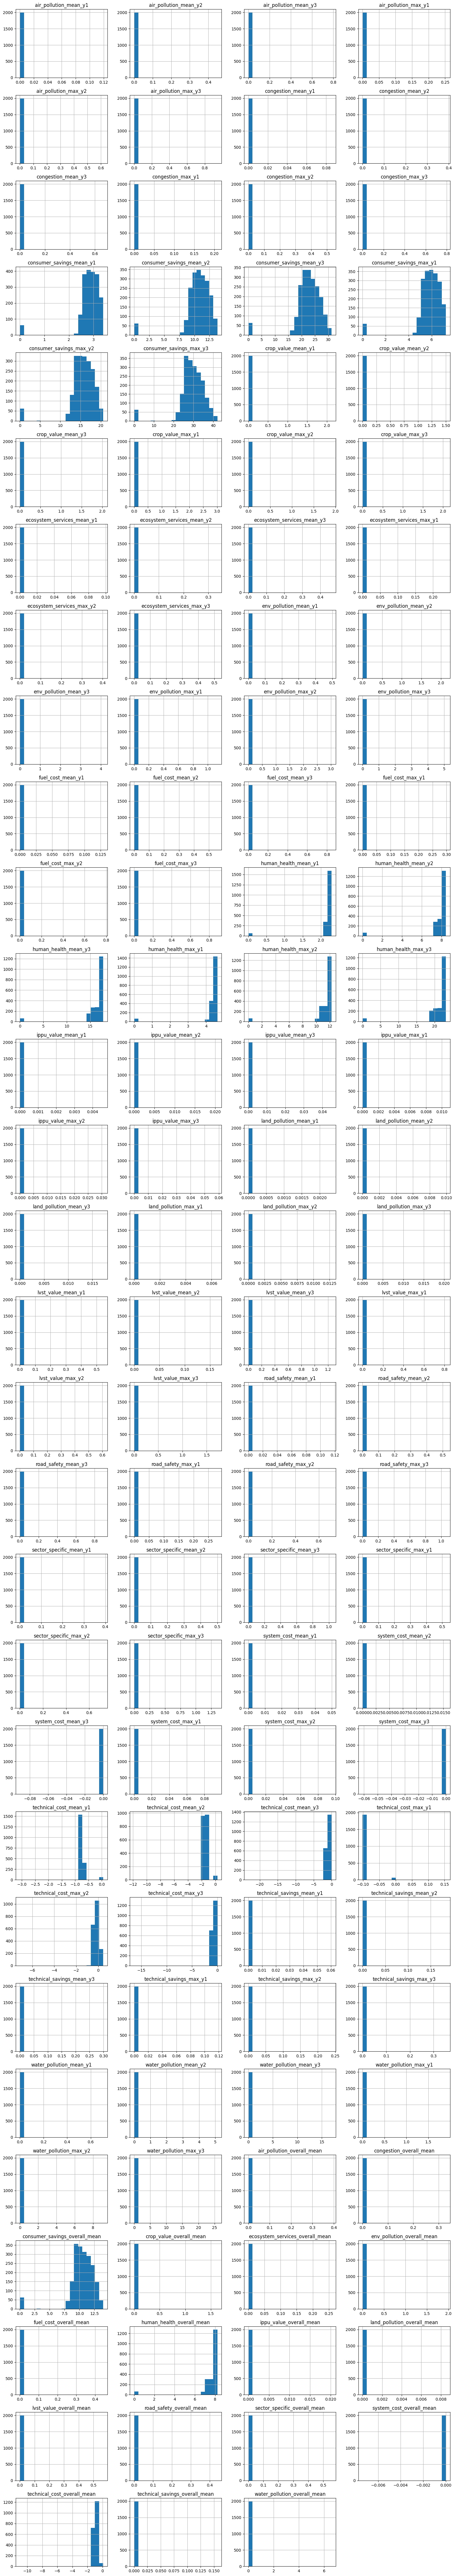

In [365]:
# columns to exclude
exclude_cols = ["primary_id"]

# select numeric columns except excluded ones
num_cols = [c for c in cb_df_agg.columns if c not in exclude_cols]

# determine subplot grid size
n = len(num_cols)
cols = 4                   # change if you want more/fewer columns of subplots
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()      # make iterable

for ax, col in zip(axes, num_cols):
    cb_df_agg[col].hist(ax=ax, bins=20)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

# hide unused subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 5) Merge emissions df with lhs samples df

In [366]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,70070,0,6004,0
2,74074,0,6008,0
3,75075,0,6009,0
4,298299,3,6004,1
...,...,...,...,...
2062,62062,0,4003,0
2063,63063,0,4004,0
2064,64064,0,4005,0
2065,66066,0,6000,0


In [367]:
# Check for duplicates in primary_id
duplicates_primary = attr_primary_df[attr_primary_df.duplicated(subset=["primary_id"], keep=False)]
if not duplicates_primary.empty:
    print("Duplicated primary_id found:")
    print(duplicates_primary)
else:
    print("No duplicated primary_id found.")

No duplicated primary_id found.


In [368]:
# Merge emissions df with the attribute primary df filtered
la_emission_df_w_future_id = la_emission_df_sum_agg.merge(attr_primary_df, on="primary_id", how="inner")

la_emission_df_w_future_id.head()

,primary_id,emission_total,design_id,strategy_id,future_id
0,0,10256.854756,0,0,0
1,1001,10256.854756,0,1000,0
2,2002,10256.854756,0,1001,0
3,3003,10256.854756,0,1002,0
4,4004,10256.854756,0,1003,0


In [369]:
# Check shape of the merged df
print(la_emission_df_sum_agg.shape)
print(la_emission_df_w_future_id.shape)

(1998, 2)
(1998, 5)


In [370]:
# Merge with cb data
la_emission_df_w_future_id_cb = la_emission_df_w_future_id.merge(cb_df_agg, on=["primary_id"], how="inner")
la_emission_df_w_future_id_cb.head()

,primary_id,emission_total,design_id,strategy_id,future_id,air_pollution_mean_y1,air_pollution_mean_y2,air_pollution_mean_y3,air_pollution_max_y1,air_pollution_max_y2,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1001,10256.854756,0,1000,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.003193,0.0,0.0
1,2002,10256.854756,0,1001,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,3003,10256.854756,0,1002,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,4004,10256.854756,0,1003,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,5005,10256.854756,0,1004,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [371]:
print("cb df_agg shape:", cb_df_agg.shape)
print("la_emission_df_w_future_id_cb shape:", la_emission_df_w_future_id_cb.shape)

cb df_agg shape: (1997, 120)
la_emission_df_w_future_id_cb shape: (1997, 124)


In [372]:
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [373]:
# Merge emissions data with lhs data
lhs_emissions_merged_df = pd.merge(lhs_df_merged, la_emission_df_w_future_id_cb, on=["design_id", "future_id"], how="inner")
lhs_emissions_merged_df.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,3,1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.738497,0.0,0.0
1,3,2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.967859,0.0,0.0
2,3,3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.837330,0.0,0.0
3,3,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.912227,0.0,0.0
4,3,5,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.780535,0.0,0.0


In [374]:
print("lhs_df_merged shape:", lhs_df_merged.shape)
print("la_emission_df_w_future_id_cb shape:", la_emission_df_w_future_id_cb.shape)
print("lhs_emissions_merged_df shape:", lhs_emissions_merged_df.shape)

lhs_df_merged shape: (4000, 94)
la_emission_df_w_future_id_cb shape: (1997, 124)
lhs_emissions_merged_df shape: (1933, 216)


In [375]:
# rearrange columns to have future_id and primary_id at the front
cols_order = ["future_id", "primary_id"] + [col for col in lhs_emissions_merged_df.columns if col not in ["future_id", "primary_id"]]
lhs_emissions_merged_df = lhs_emissions_merged_df[cols_order]
lhs_emissions_merged_df

,future_id,primary_id,design_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1,298299,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.738497,0.0,0.0
1,2,298300,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.967859,0.0,0.0
2,3,298301,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.837330,0.0,0.0
3,4,298302,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.912227,0.0,0.0
4,5,298303,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.780535,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,996,375370,4,0.059039,0.417728,0.091020,0.318165,0.645634,0.513777,0.574314,...,7.589705,0.0,0.0,0.0,0.0,0.0,0.0,-0.976165,0.0,0.0
1929,997,375371,4,0.461471,0.491210,0.210822,0.844321,0.633153,0.599206,0.763054,...,7.701604,0.0,0.0,0.0,0.0,0.0,0.0,-0.937427,0.0,0.0
1930,998,375372,4,0.723537,0.180950,0.551961,0.158086,0.882026,0.818294,0.505303,...,7.988576,0.0,0.0,0.0,0.0,0.0,0.0,-1.011258,0.0,0.0
1931,999,375373,4,0.479683,0.722598,0.275481,0.613768,0.764342,0.850816,0.851390,...,8.031176,0.0,0.0,0.0,0.0,0.0,0.0,-0.875569,0.0,0.0


In [376]:
# Drop some unnecessary columns
lhs_emissions_merged_df = lhs_emissions_merged_df.drop(columns=["design_id",
                                                                "strategy_id"])

In [377]:
# Check for nans
lhs_emissions_merged_df.isna().sum().sum()

np.int64(0)

## Filter out irrelevant lhs groups

In [378]:
var_traj_X_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_X.csv"))
var_traj_L_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [379]:
# add suffix to items in variable_trajectory_group field items
var_traj_X_df["variable_trajectory_group_w_suffix"] = var_traj_X_df["variable_trajectory_group"].astype(str) + '_X'
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [380]:
# add suffix to items in variable_trajectory_group field items
var_traj_L_df["variable_trajectory_group_w_suffix"] = var_traj_L_df["variable_trajectory_group"].astype(str) + '_L'
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
559,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
560,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
561,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
562,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [381]:
var_traj_groups_X = var_traj_X_df["variable_trajectory_group_w_suffix"].unique()
var_traj_groups_L = var_traj_L_df["variable_trajectory_group_w_suffix"].unique()
print("Variable trajectory groups X:", var_traj_groups_X)
print("Variable trajectory groups L:", var_traj_groups_L)

Variable trajectory groups X: ['60_X' '61_X' '62_X' '63_X' '64_X' '65_X' '66_X' '67_X' '68_X']
Variable trajectory groups L: ['1_L' '2_L' '3_L' '4_L' '5_L' '6_L' '7_L' '8_L' '9_L' '10_L' '11_L'
 '12_L' '13_L' '14_L' '15_L' '16_L' '17_L' '18_L' '19_L' '20_L' '21_L'
 '22_L' '23_L' '24_L' '25_L' '26_L' '27_L' '28_L' '29_L' '30_L' '31_L'
 '32_L' '33_L' '34_L' '35_L' '36_L' '37_L' '38_L' '39_L' '40_L' '41_L'
 '42_L' '43_L' '44_L' '45_L' '46_L' '47_L' '48_L' '49_L' '50_L' '51_L'
 '52_L' '53_L' '54_L' '55_L' '56_L' '57_L' '58_L' '59_L']


In [382]:
# join the var_traj_groups
var_traj_groups_all = var_traj_groups_X.tolist() + var_traj_groups_L.tolist()
var_traj_groups_all = list(set(var_traj_groups_all))  # remove duplicates
print("All variable trajectory groups:", var_traj_groups_all)

All variable trajectory groups: ['29_L', '48_L', '58_L', '9_L', '63_X', '66_X', '51_L', '34_L', '2_L', '56_L', '59_L', '23_L', '53_L', '38_L', '42_L', '25_L', '26_L', '57_L', '55_L', '61_X', '68_X', '5_L', '15_L', '40_L', '13_L', '8_L', '21_L', '19_L', '30_L', '18_L', '24_L', '65_X', '37_L', '35_L', '22_L', '33_L', '7_L', '36_L', '20_L', '10_L', '11_L', '12_L', '17_L', '60_X', '28_L', '4_L', '6_L', '14_L', '54_L', '47_L', '43_L', '67_X', '46_L', '45_L', '62_X', '44_L', '64_X', '50_L', '39_L', '1_L', '3_L', '41_L', '49_L', '52_L', '16_L', '27_L', '32_L', '31_L']


In [383]:
df_cols = lhs_emissions_merged_df.columns.tolist()

# Filter the relevant_lhs_cols to only include those that are in df_cols
relevant_lhs_cols = [col for col in var_traj_groups_all if col in df_cols]

In [385]:
lhs_emissions_merged_df.head()

,future_id,primary_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1,298299,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.738497,0.0,0.0
1,2,298300,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.967859,0.0,0.0
2,3,298301,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.837330,0.0,0.0
3,4,298302,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.912227,0.0,0.0
4,5,298303,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.780535,0.0,0.0


In [389]:
target_fields = [
    col
    for col in lhs_emissions_merged_df.columns
    if not col.endswith(('_X', '_L')) and col not in ["future_id", "primary_id"]
]

target_fields

['emission_total',
 'air_pollution_mean_y1',
 'air_pollution_mean_y2',
 'air_pollution_mean_y3',
 'air_pollution_max_y1',
 'air_pollution_max_y2',
 'air_pollution_max_y3',
 'congestion_mean_y1',
 'congestion_mean_y2',
 'congestion_mean_y3',
 'congestion_max_y1',
 'congestion_max_y2',
 'congestion_max_y3',
 'consumer_savings_mean_y1',
 'consumer_savings_mean_y2',
 'consumer_savings_mean_y3',
 'consumer_savings_max_y1',
 'consumer_savings_max_y2',
 'consumer_savings_max_y3',
 'crop_value_mean_y1',
 'crop_value_mean_y2',
 'crop_value_mean_y3',
 'crop_value_max_y1',
 'crop_value_max_y2',
 'crop_value_max_y3',
 'ecosystem_services_mean_y1',
 'ecosystem_services_mean_y2',
 'ecosystem_services_mean_y3',
 'ecosystem_services_max_y1',
 'ecosystem_services_max_y2',
 'ecosystem_services_max_y3',
 'env_pollution_mean_y1',
 'env_pollution_mean_y2',
 'env_pollution_mean_y3',
 'env_pollution_max_y1',
 'env_pollution_max_y2',
 'env_pollution_max_y3',
 'fuel_cost_mean_y1',
 'fuel_cost_mean_y2',
 'fuel_

In [390]:
# filter to keep only relevant columns
cols_to_keep = ["future_id", "primary_id"] + list(relevant_lhs_cols) + target_fields
merged_df_filtered = lhs_emissions_merged_df[cols_to_keep]

In [391]:
print("Original merged DataFrame shape:", lhs_emissions_merged_df.shape)
print("Filtered merged DataFrame shape:", merged_df_filtered.shape)

Original merged DataFrame shape: (1933, 214)
Filtered merged DataFrame shape: (1933, 190)


In [392]:
print("Filtered merged DataFrame fields:", merged_df_filtered.columns.tolist())
print("Relevant LHS columns:", relevant_lhs_cols)

Filtered merged DataFrame fields: ['future_id', 'primary_id', '29_L', '48_L', '58_L', '9_L', '63_X', '66_X', '51_L', '34_L', '2_L', '56_L', '59_L', '23_L', '53_L', '38_L', '42_L', '25_L', '26_L', '57_L', '55_L', '61_X', '68_X', '5_L', '15_L', '40_L', '13_L', '8_L', '21_L', '19_L', '30_L', '18_L', '24_L', '65_X', '37_L', '35_L', '22_L', '33_L', '7_L', '36_L', '20_L', '10_L', '11_L', '12_L', '17_L', '60_X', '28_L', '4_L', '6_L', '14_L', '54_L', '47_L', '43_L', '67_X', '46_L', '45_L', '62_X', '44_L', '64_X', '50_L', '39_L', '1_L', '3_L', '41_L', '49_L', '52_L', '16_L', '27_L', '32_L', '31_L', 'emission_total', 'air_pollution_mean_y1', 'air_pollution_mean_y2', 'air_pollution_mean_y3', 'air_pollution_max_y1', 'air_pollution_max_y2', 'air_pollution_max_y3', 'congestion_mean_y1', 'congestion_mean_y2', 'congestion_mean_y3', 'congestion_max_y1', 'congestion_max_y2', 'congestion_max_y3', 'consumer_savings_mean_y1', 'consumer_savings_mean_y2', 'consumer_savings_mean_y3', 'consumer_savings_max_y1'

In [393]:
print([col for col in lhs_emissions_merged_df.columns if 'X' in col])
print([col for col in merged_df_filtered.columns if 'X' in col])

['60_X', '61_X', '62_X', '63_X', '64_X', '65_X', '66_X', '67_X', '68_X']
['63_X', '66_X', '61_X', '68_X', '65_X', '60_X', '67_X', '62_X', '64_X']


In [394]:
print([col for col in lhs_emissions_merged_df.columns if 'L' in col])
print([col for col in merged_df_filtered.columns if 'L' in col])

['1_L', '2_L', '3_L', '4_L', '5_L', '6_L', '7_L', '8_L', '9_L', '10_L', '11_L', '12_L', '13_L', '14_L', '15_L', '16_L', '17_L', '18_L', '19_L', '20_L', '21_L', '22_L', '23_L', '24_L', '25_L', '26_L', '27_L', '28_L', '29_L', '30_L', '31_L', '32_L', '33_L', '34_L', '35_L', '36_L', '37_L', '38_L', '39_L', '40_L', '41_L', '42_L', '43_L', '44_L', '45_L', '46_L', '47_L', '48_L', '49_L', '50_L', '51_L', '52_L', '53_L', '54_L', '55_L', '56_L', '57_L', '58_L', '59_L', '80_L', '1138_L', '1145_L', '1148_L', '1266_L', '1665_L', '1666_L', '1669_L', '1672_L', '1674_L', '1675_L', '1704_L', '1708_L', '1709_L', '1711_L', '1712_L', '1714_L', '1726_L', '1727_L', '1730_L', '1731_L', '1733_L', '1735_L', '1736_L']
['29_L', '48_L', '58_L', '9_L', '51_L', '34_L', '2_L', '56_L', '59_L', '23_L', '53_L', '38_L', '42_L', '25_L', '26_L', '57_L', '55_L', '5_L', '15_L', '40_L', '13_L', '8_L', '21_L', '19_L', '30_L', '18_L', '24_L', '37_L', '35_L', '22_L', '33_L', '7_L', '36_L', '20_L', '10_L', '11_L', '12_L', '17_L'

In [395]:
merged_df_filtered.head()

,future_id,primary_id,29_L,48_L,58_L,9_L,63_X,66_X,51_L,34_L,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1,298299,0.442982,0.391066,0.561448,0.612787,-1.0,-1.0,0.658591,0.261520,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.738497,0.0,0.0
1,2,298300,0.121257,0.201058,0.698696,0.277691,-1.0,-1.0,0.450296,0.256987,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.967859,0.0,0.0
2,3,298301,0.202128,0.184524,0.915434,0.152778,-1.0,-1.0,0.657645,0.188361,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.837330,0.0,0.0
3,4,298302,0.205361,0.467632,0.527528,0.356106,-1.0,-1.0,0.624417,0.406938,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.912227,0.0,0.0
4,5,298303,0.460605,0.996007,0.500024,0.898125,-1.0,-1.0,0.313340,0.589794,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.780535,0.0,0.0


In [396]:
merged_df_filtered.columns

Index(['future_id', 'primary_id', '29_L', '48_L', '58_L', '9_L', '63_X',
       '66_X', '51_L', '34_L',
       ...
       'human_health_overall_mean', 'ippu_value_overall_mean',
       'land_pollution_overall_mean', 'lvst_value_overall_mean',
       'road_safety_overall_mean', 'sector_specific_overall_mean',
       'system_cost_overall_mean', 'technical_cost_overall_mean',
       'technical_savings_overall_mean', 'water_pollution_overall_mean'],
      dtype='object', length=190)

## Add variable names to lhs columns

In [399]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
559,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
560,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
561,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
562,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [400]:
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [401]:
subset_cols = ["variable", "variable_trajectory_group_w_suffix"]
var_traj_all_df = pd.concat([var_traj_X_df[subset_cols], var_traj_L_df[subset_cols]], ignore_index=True)
var_traj_all_df

,variable,variable_trajectory_group_w_suffix
0,exports_agrc_bevs_and_spices_tonne,60_X
1,exports_agrc_cereals_tonne,60_X
2,exports_agrc_fibers_tonne,60_X
3,exports_agrc_fruits_tonne,60_X
4,exports_agrc_herbs_and_other_perennial_crops_t...,60_X
...,...,...
617,Fraction of Waste Recycled,59_L
618,Fraction of Waste Recycled,59_L
619,Fraction of Waste Recycled,59_L
620,Fraction of Waste Recycled,59_L


In [402]:
# drop duplicates if any
print("Before dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df.drop_duplicates(subset=subset_cols)
print("After dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)

Before dropping duplicates, var_traj_all_df shape: (622, 2)
After dropping duplicates, var_traj_all_df shape: (186, 2)


In [403]:
# check if there are any duplicated variable names
duplicated_vars = var_traj_all_df["variable"].duplicated().any()
if duplicated_vars:
    print("There are duplicated variable names in var_traj_all_df.")
else:
    print("No duplicated variable names in var_traj_all_df.")

There are duplicated variable names in var_traj_all_df.


In [404]:
# Filter var_traj_all_df by sample_group in relevant_lhs_cols
print("Before filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df[var_traj_all_df["variable_trajectory_group_w_suffix"].isin(relevant_lhs_cols)]
var_traj_all_df = var_traj_all_df.sort_values(by="variable_trajectory_group_w_suffix", ascending=True)
print("After filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)

Before filtering by relevant_lhs_cols, var_traj_all_df shape: (186, 2)
After filtering by relevant_lhs_cols, var_traj_all_df shape: (186, 2)


In [405]:
def process_variable_prefix(df, var_col='variable', group_col='variable_trajectory_group_w_suffix'):
    result = []
    for group, group_df in df.groupby(group_col):
        variables = group_df[var_col].tolist()
        if len(variables) == 1:
            prefix = variables[0]
        else:
            prefix = os.path.commonprefix(variables)
            # Clean trailing underscores
            prefix = prefix.rstrip('_')
            
        prefix = f"group_{group}_{prefix}"
        result.append({'variable_trajectory_group_w_suffix': group, 'variable_prefix': prefix})
    return pd.DataFrame(result)

prefix_df = process_variable_prefix(var_traj_all_df)
prefix_df

,variable_trajectory_group_w_suffix,variable_prefix
0,10_L,group_10_L_Fraction Non-Fugitive :math:\text{C...
1,11_L,group_11_L_Forest Sequestration Emission Factor
2,12_L,group_12_L_Average Industrial Energy Fuel Effi...
3,13_L,group_13_L_Industrial Energy Demand Scalar
4,14_L,group_14_L_Industrial Energy Fuel Fraction
...,...,...
63,68_X,group_68_X_elasticity_trde_pkm_to_gdppc
64,6_L,group_6_L_Electrical Transmission Loss Fraction
65,7_L,group_7_L_NemoMod MinShareProduction
66,8_L,group_8_L_NemoMod


In [406]:
# Check for duplicates in variable_trajectory_group_w_suffix and variable_prefix
dups = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix", "variable_prefix"], keep=False)
if dups.any():
    print("Duplicated variable_trajectory_group_w_suffix and variable_prefix found:")
    print(prefix_df[dups])
else:
    print("No duplicated variable_trajectory_group_w_suffix and variable_prefix found.")

# Check for duplicates in variable_trajectory_group_w_suffix
dups_group = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix"], keep=False)
if dups_group.any():
    print("Duplicated variable_trajectory_group_w_suffix found:")
    print(prefix_df[dups_group])
else:
    print("No duplicated variable_trajectory_group_w_suffix found.")

# Check for duplicates in variable_prefix
dups_prefix = prefix_df.duplicated(subset=["variable_prefix"], keep=False)
if dups_prefix.any():
    print("Duplicated variable_prefix found:")
    print(prefix_df[dups_prefix])
else:
    print("No duplicated variable_prefix found.")

No duplicated variable_trajectory_group_w_suffix and variable_prefix found.
No duplicated variable_trajectory_group_w_suffix found.
No duplicated variable_prefix found.


In [407]:
# var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin([3, 13, 40])]

In [408]:
# prefix_df.loc[prefix_df["sample_group"] == 13, "variable_prefix"] = "group_13_frac_gnrl_eating_red_meats+"
# prefix_df.loc[prefix_df["sample_group"] == 40, "variable_prefix"] = "group_40_pij_lndu_grasslands+"

# prefix_df = prefix_df.sort_values(by="variable_prefix", ascending=True)
# prefix_df

In [409]:
# Let's use the prefix_df to rename the columns in merged_df_filtered
def rename_columns_with_prefix(merged_df, prefix_df):
    df = merged_df.copy()
    # Create a mapping from str(group) to prefix
    group_to_prefix = {str(row['variable_trajectory_group_w_suffix']): row['variable_prefix'] for _, row in prefix_df.iterrows()}
    # Only rename columns that match a group
    rename_dict = {col: group_to_prefix[col] for col in df.columns if col in group_to_prefix}
    df = df.rename(columns=rename_dict)
    return df

merged_df_filtered_w_prefix = rename_columns_with_prefix(merged_df_filtered, prefix_df)

In [410]:
merged_df_filtered_w_prefix

,future_id,primary_id,group_29_L_Fraction Eating Red Meat,group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants,group_58_L_Fraction of Non-Recycled Solid Waste,group_9_L_,group_63_X_elasticity_ippu,group_66_X_elasticity_scoe_enerdem_per,group_51_L_Treatment Fraction,group_34_L_SCOE Fraction Heat Energy Demand,...,human_health_overall_mean,ippu_value_overall_mean,land_pollution_overall_mean,lvst_value_overall_mean,road_safety_overall_mean,sector_specific_overall_mean,system_cost_overall_mean,technical_cost_overall_mean,technical_savings_overall_mean,water_pollution_overall_mean
0,1,298299,0.442982,0.391066,0.561448,0.612787,-1.000000,-1.000000,0.658591,0.261520,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.738497,0.0,0.0
1,2,298300,0.121257,0.201058,0.698696,0.277691,-1.000000,-1.000000,0.450296,0.256987,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.967859,0.0,0.0
2,3,298301,0.202128,0.184524,0.915434,0.152778,-1.000000,-1.000000,0.657645,0.188361,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.837330,0.0,0.0
3,4,298302,0.205361,0.467632,0.527528,0.356106,-1.000000,-1.000000,0.624417,0.406938,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.912227,0.0,0.0
4,5,298303,0.460605,0.996007,0.500024,0.898125,-1.000000,-1.000000,0.313340,0.589794,...,7.899122,0.0,0.0,0.0,0.0,0.0,0.0,-0.780535,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,996,375370,0.959036,0.533798,0.070134,0.208956,0.318165,0.574314,0.816168,0.769879,...,7.589705,0.0,0.0,0.0,0.0,0.0,0.0,-0.976165,0.0,0.0
1929,997,375371,0.487597,0.500735,0.612439,0.525971,0.844321,0.763054,0.741635,0.229468,...,7.701604,0.0,0.0,0.0,0.0,0.0,0.0,-0.937427,0.0,0.0
1930,998,375372,0.183458,0.040459,0.505808,0.388833,0.158086,0.505303,0.051559,0.782813,...,7.988576,0.0,0.0,0.0,0.0,0.0,0.0,-1.011258,0.0,0.0
1931,999,375373,0.796752,0.446319,0.616741,0.192289,0.613768,0.851390,0.636352,0.722648,...,8.031176,0.0,0.0,0.0,0.0,0.0,0.0,-0.875569,0.0,0.0


In [411]:
print(merged_df_filtered.shape)
print(merged_df_filtered_w_prefix.shape)

(1933, 190)
(1933, 190)


In [412]:
# check for duplicated column names
duplicated_cols = merged_df_filtered_w_prefix.columns[merged_df_filtered_w_prefix.columns.duplicated()].tolist()
if duplicated_cols:
    print("Duplicated column names found:", duplicated_cols)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## Finally we save the processed data as training data

In [413]:
# Create training directory if it doesn't exist
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

In [414]:
#save the merged DataFrame to a CSV file
merged_df_filtered_w_prefix.to_csv(os.path.join(TRAINING_DIR_PATH, "training_data_w_suffix.csv"), index=False)

In [415]:
# save the version without suffix for backward compatibility
merged_df_filtered.to_csv(os.path.join(TRAINING_DIR_PATH, "training_data.csv"), index=False)